# Aufgabe 2

In [86]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.color import rgb2gray
from skimage.filters import gaussian, sobel_h, sobel_v
from skimage.io import imread

## 2.1

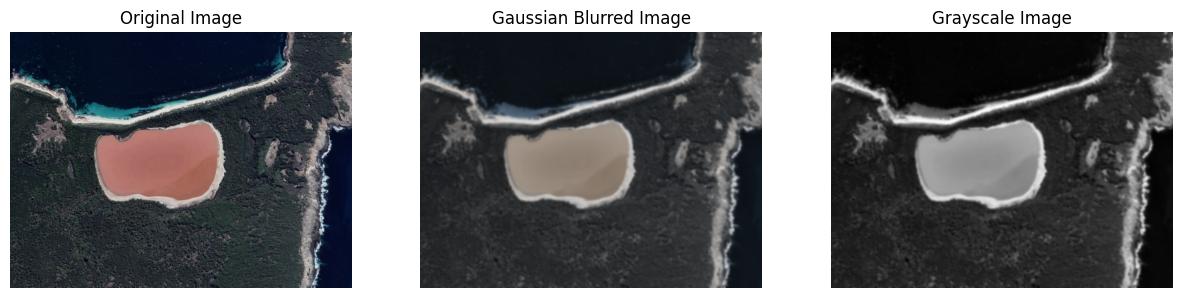

In [87]:
lake_img = imread('lake.png')

lake_gauss = gaussian(lake_img, sigma=2)

lake_gray = rgb2gray(lake_gauss)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(lake_img)
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(lake_gauss)
axes[1].set_title('Gaussian Blurred Image')
axes[1].axis('off')

axes[2].imshow(lake_gray, cmap='gray')
axes[2].set_title('Grayscale Image')
axes[2].axis('off')
plt.show()

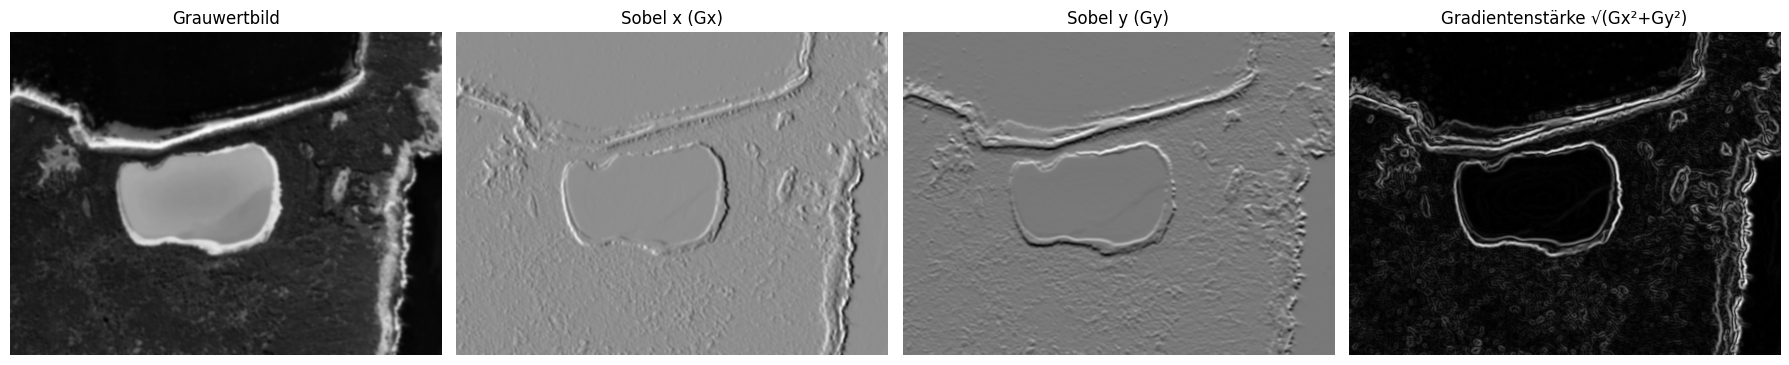

In [88]:

# Sobel-Operatoren in x- und y-Richtung
grad_x = sobel_v(lake_gray)  # vertikale Kanten (Gradient in x-Richtung)
grad_y = sobel_h(lake_gray)  # horizontale Kanten (Gradient in y-Richtung)

# Gradientenstärke (Magnitude)
grad_magnitude = np.sqrt(grad_x**2 + grad_y**2)

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

axes[0].imshow(lake_gray, cmap='gray')
axes[0].set_title('Grauwertbild')
axes[0].axis('off')

axes[1].imshow(grad_x, cmap='gray')
axes[1].set_title('Sobel x (Gx)')
axes[1].axis('off')

axes[2].imshow(grad_y, cmap='gray')
axes[2].set_title('Sobel y (Gy)')
axes[2].axis('off')

axes[3].imshow(grad_magnitude, cmap='gray')
axes[3].set_title('Gradientenstärke √(Gx²+Gy²)')
axes[3].axis('off')

plt.tight_layout()
plt.show()


Es werden die Kanten Wasser-Sand und Sand-Wald gefunden.<br>
Die Kanten zwischen Sand-Wald sind stärker.

## 2.2

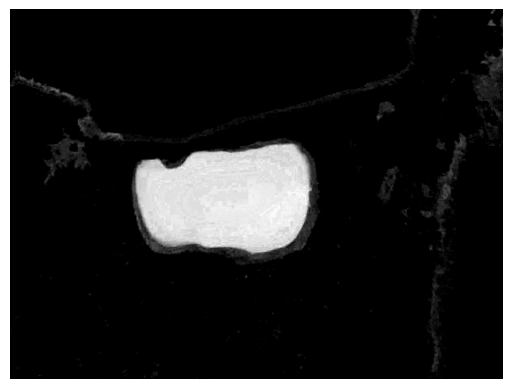

In [89]:

R = lake_img[:, :, 0].astype(float)
G = lake_img[:, :, 1].astype(float)
B = lake_img[:, :, 2].astype(float)

redness = R - (G + B)/2
redness = np.maximum(redness, 0)

# Kontraststreckung auf [0, 255]
redness_stretched = (redness - redness.min()) / (redness.max() - redness.min()) * 255

plt.imshow(redness_stretched, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()


## 2.3

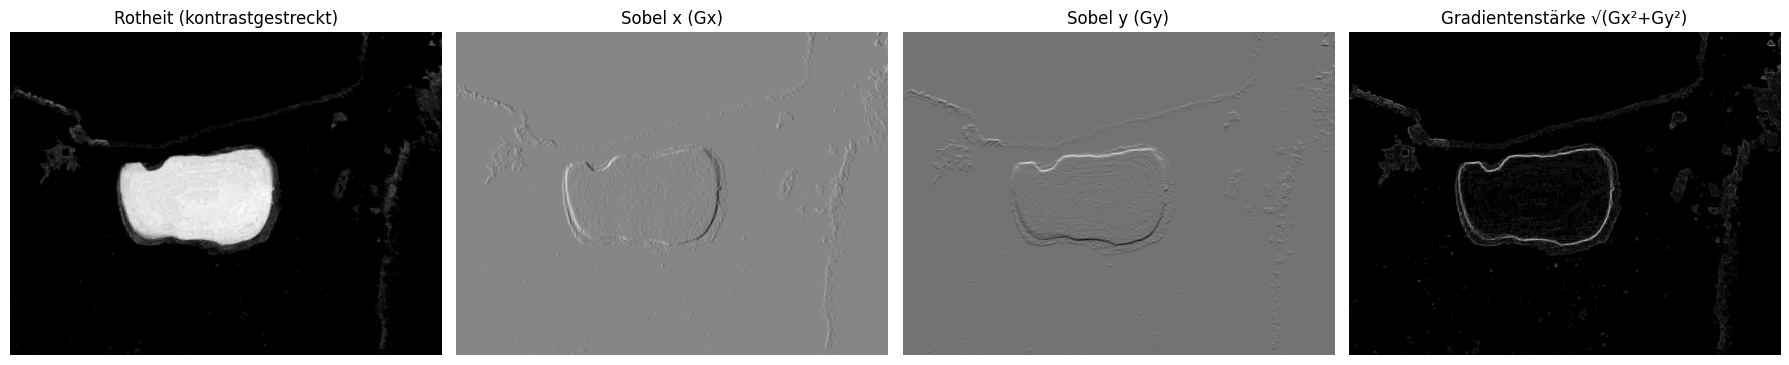

In [90]:
red_grad_x = sobel_v(redness_stretched)
red_grad_y = sobel_h(redness_stretched)

red_grad_magnitude = np.sqrt(red_grad_x**2 + red_grad_y**2)

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

axes[0].imshow(redness_stretched, cmap='gray')
axes[0].set_title('Rotheit (kontrastgestreckt)')
axes[0].axis('off')

axes[1].imshow(red_grad_x, cmap='gray')
axes[1].set_title('Sobel x (Gx)')
axes[1].axis('off')

axes[2].imshow(red_grad_y, cmap='gray')
axes[2].set_title('Sobel y (Gy)')
axes[2].axis('off')

axes[3].imshow(red_grad_magnitude, cmap='gray')
axes[3].set_title('Gradientenstärke √(Gx²+Gy²)')
axes[3].axis('off')

plt.tight_layout()
plt.show()

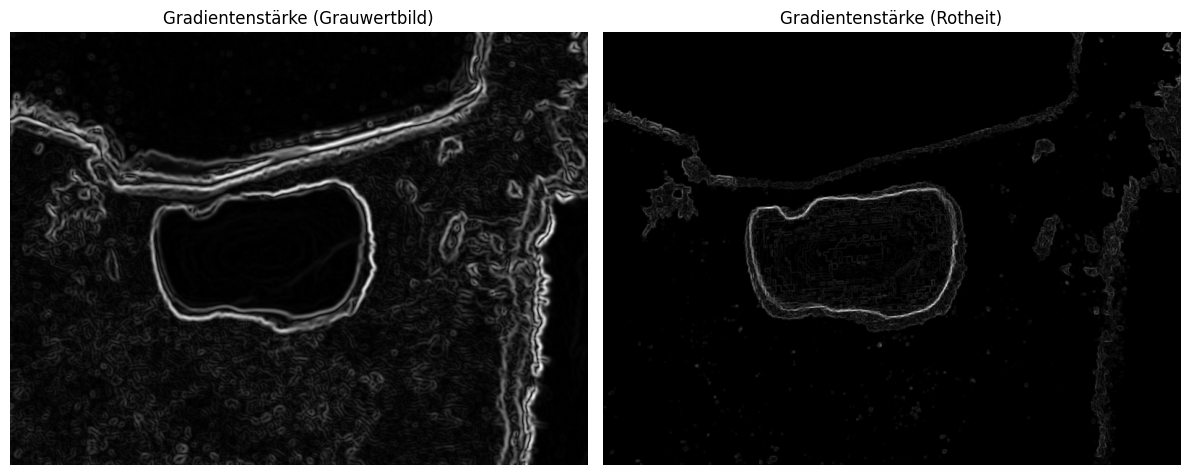

In [91]:
# Vergleich
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(grad_magnitude, cmap='gray')
axes[0].set_title('Gradientenstärke (Grauwertbild)')
axes[0].axis('off')

axes[1].imshow(red_grad_magnitude, cmap='gray')
axes[1].set_title('Gradientenstärke (Rotheit)')
axes[1].axis('off')
plt.tight_layout()
plt.show()

Nach der Transformation zur Rotheit sticht die Umrandung des Sees im Vergleich zu anderen Kanten stärker hervor. Allerdings sind andere Kanten (vor allem von Stränden) noch immer erkennbar, da der helle Sand auch Rottöne enthält.<br>
Das Ergbnis in Bezug auf den See ist aber viel besser.